In [12]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": "Helvetica",
    "figure.dpi": 300,
})

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Empirical Demonstrations

## The Fourier coefficients of the discrete derivative kernel

Given any normalized complex function $f: \{0,1,\dots,N-1\}$, its discrete derivative is defined to be:

$$
\dfrac{\Delta f}{\Delta x} = f(x + 1) - f(x)
$$

Let $d$ be the kernel $\{1,-1,0,\dots,0\}$.
The convolution between $f$ and $d$ is then:

$$
    f * d = \dfrac{\Delta f}{\Delta x}
$$

The figure below shows that:
- the magnitude of the Fourier coefficients of $d$ is proportional to the $\sin$ function and
- the phase of the Fourier coefficients is linear between $\frac{\pi}{2}$ and $-\frac{\pi}{2}$.

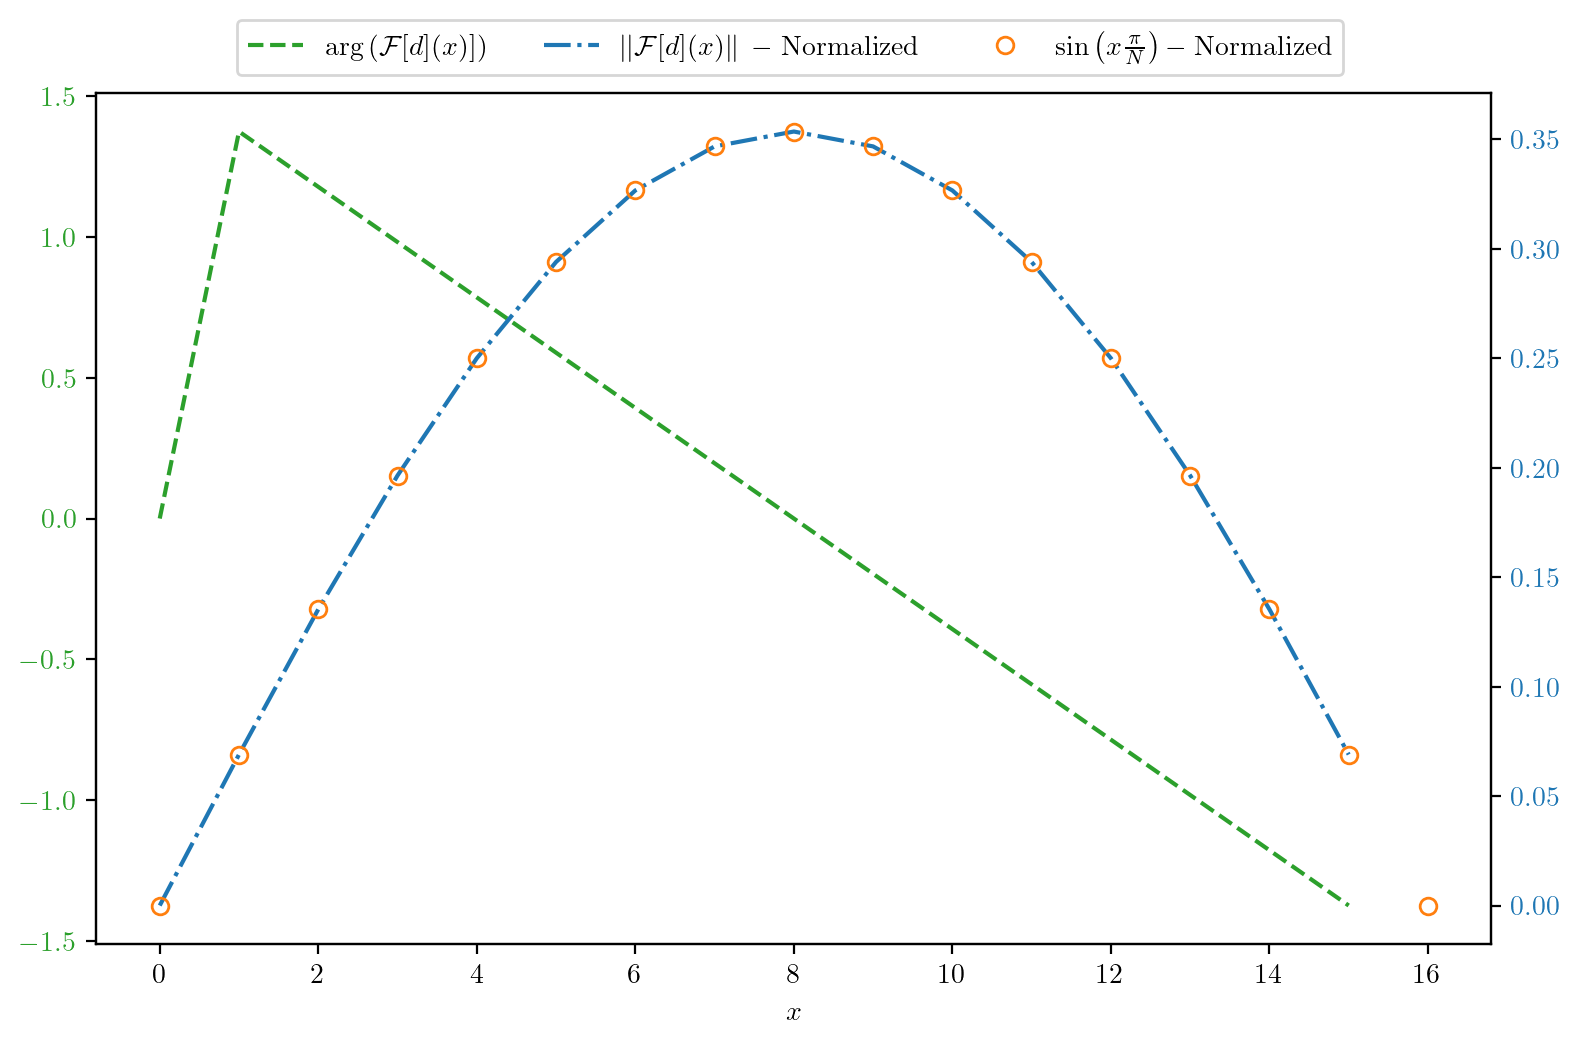

In [356]:
def plot_d_fourier_coefficients(resolution=10):
    d = [1,-1]
    d_kernel = np.array(d + [0]*(2**resolution - len(d)), dtype=float)
    d_hat = np.fft.fft(d_kernel)
    d_hat /= np.linalg.norm(d_hat)
    sin_function = np.sin(np.linspace(start=0, stop=np.pi, num=len(d_hat)+1))
    sin_function /= np.linalg.norm(sin_function)

    magnitude = np.abs(d_hat)
    phase = np.angle(d_hat)

    fig, ax1 = plt.subplots(figsize=(8,5), dpi=200)
    ax1.set_xlabel('$x$')
    ax2 = ax1.twinx()

    # Plot Phase
    color = 'C2'
    ax1.plot(phase, "--", label=r"$\arg\left(\mathcal{F}[d](x)]\right)$", color=color)
    ax1.tick_params(axis='y',  labelcolor=color)

    # Plot Magnitude
    color = 'C0'
    ax2.plot(magnitude, "-.", label=r"$\left|\left| \mathcal{F}[d](x)\right|\right| \rm{\ -\ Normalized}$")
    ax2.plot(sin_function, "o", mfc="none", label=r"$\sin\left(x\frac{\pi}{N}\right) \rm{ -\ Normalized}$")
    ax2.tick_params(axis='y', labelcolor=color)

    fig.tight_layout()

    fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=3)

plot_d_fourier_coefficients(4)
plt.show()

## Convolution Theorem (CT)

In [14]:
%%capture

def verify_convolution_theorem(f, h):
    expected = np.convolve(f, h)
    padded_f = np.pad(f, (0, len(h) - 1), 'constant')
    padded_h = np.pad(h, (0, len(f) - 1), 'constant')
    actual = np.fft.ifft(np.fft.fft(padded_f) * np.fft.fft(padded_h))
    assert np.allclose(
        (expected/np.linalg.norm(expected)),
        (actual/np.linalg.norm(actual))
    )
    return actual

np.random.seed(42)
verify_convolution_theorem(
    np.random.rand(5),
    np.random.rand(7)
)

## Discrete derivative via the Convolution Theorem

In [394]:
%%capture

def verify_1st_derivative(f):
    d = np.array([1, -1])
    padded_f = np.pad(f, (0, len(d) - 1), 'constant')
    padded_d = np.pad(d, (0, len(f) - 1), 'constant')

    # Verify the construction of the first discrete derivative
    df = np.pad(f, (0, 1), 'constant')
    for i in range(1, len(df)):
        df[i] -= f[i - 1]
    convolution = np.convolve(d, f)
    assert np.allclose(df, convolution)

    # Verify the convolution theorem for f and d
    expected = verify_convolution_theorem(d, f)
    assert np.allclose(expected, convolution)

    # Construct the fourier coefficients of d as a sin function
    theta = np.linspace(start=0, stop=np.pi, num=len(f) + 2)[:-1]
    magnitude = np.sin(theta)
    phase = np.exp(1j * (np.pi / 2 - theta))
    coefficients = magnitude * phase

    # Verify the Fourier coefficients of d, up to normalization
    d_hat = np.fft.fft(padded_d)
    assert np.allclose(
        coefficients/np.linalg.norm(coefficients),
        d_hat/np.linalg.norm(d_hat)
    )

    # Compute the convolution as a pointwise product between
    # - the Fourier coefficients of f, calculated via np.fft.fft and
    # - the Fourier coefficients of d, calculated as direct polar coordinates
    actual = np.fft.ifft(np.fft.fft(padded_f) * coefficients)

    assert np.allclose(actual/np.linalg.norm(actual), expected/np.linalg.norm(expected))

    return actual

np.random.seed(42)
verify_1st_derivative(np.random.rand(2**10 - 1))

## Discrete derivative via state vector simulation

In [397]:
from qpte import Block
from experiments import benchmark_dx2 as simulate

def verify_simulation(f, derivative, qubits):
    padded_f = np.pad(f, (0, derivative - 1), 'constant')

    expected = f
    for k in range(derivative):
        expected = verify_1st_derivative(expected)

    actual = simulate.derivative(Block(0, padded_f, qubits), k=derivative)[0]

    assert np.allclose(
        actual/np.linalg.norm(actual),
        expected/np.linalg.norm(expected)
    )

np.random.seed(42)
verify_simulation(np.random.rand(2**7 - 2), 2, 7)